In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("imdb_top_1000.csv")
print(f"row:{df.shape[0]},column:{df.shape[1]}")


row:1000,column:16


In [2]:
df["Runtime_min"] = df["Runtime"].str.split(' ').str[0].astype(float)

df["Runtime_min"].describe()

count    1000.000000
mean      122.891000
std        28.093671
min        45.000000
25%       103.000000
50%       119.000000
75%       137.000000
max       321.000000
Name: Runtime_min, dtype: float64

In [3]:
bins = range(0, 331, 30)


freq = pd.cut(df['Runtime_min'], bins=bins).value_counts().sort_index()
total = freq.values.sum()

relative_freq = (freq.values / total * 100).round(2)

cumulative_freq = freq.values.cumsum()

cumulative_rel_freq = (cumulative_freq / total * 100).round(2)

freq_table = pd.DataFrame({
    'Class Interval':     freq.index.astype(str),
    'Frequency':          freq.values,
    'Relative Freq (%)':  relative_freq,
    'Cumulative Freq':    cumulative_freq,
    'Cumulative Rel (%)': cumulative_rel_freq
})


print("FREQUENCY TABLE")
print(freq_table.to_string(index=False))
print(f"  TOTAL     {total}        100.00%")


FREQUENCY TABLE
Class Interval  Frequency  Relative Freq (%)  Cumulative Freq  Cumulative Rel (%)
       (0, 30]          0                0.0                0                 0.0
      (30, 60]          1                0.1                1                 0.1
      (60, 90]         77                7.7               78                 7.8
     (90, 120]        445               44.5              523                52.3
    (120, 150]        330               33.0              853                85.3
    (150, 180]        107               10.7              960                96.0
    (180, 210]         32                3.2              992                99.2
    (210, 240]          6                0.6              998                99.8
    (240, 270]          1                0.1              999                99.9
    (270, 300]          0                0.0              999                99.9
    (300, 330]          1                0.1             1000               100.0


In [4]:
mean_runtime = df["Runtime_min"].mean()
median_runtime = df["Runtime_min"].median()
mode_runtime = df["Runtime_min"].mode()[0]
std_runtime = df["Runtime_min"].std()
skewness = df["Runtime_min"].skew()
modal_class = freq.idxmax()



print("Mean:", round(mean_runtime,2))
print("Median:", median_runtime)
print("Mode:", mode_runtime)
print("Modal class:", modal_class)
print("Standard Deviation:", round(std_runtime,2))
print("Skewness:", round(skewness,2))

Mean: 122.89
Median: 119.0
Mode: 100.0
Modal class: (90, 120]
Standard Deviation: 28.09
Skewness: 1.21


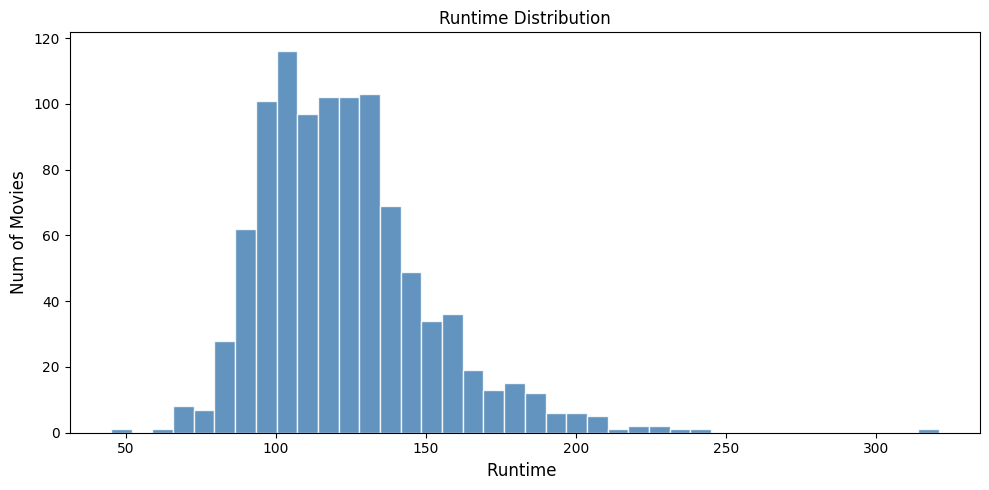

In [7]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['Runtime_min'].dropna(),
        bins=40,
        color='steelblue',
        edgecolor='white',
        alpha=0.85)



ax.set_xlabel('Runtime ', fontsize=12)
ax.set_ylabel('Num of Movies', fontsize=12)


ax.set_title('Runtime Distribution', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
print("Mean > Median")
print("the distribution of skewed is right.since distribution leans left with a long tail on the right")

Mean > Median
the distribution of skewed is right.since distribution leans left with a long tail on the right
